# MSE 5720 Assignment 3
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

##### All shell scripts, original input files, and output files can be found in the GitHub repository: https://github.com/chemerzhc/Cornell-MSE5720-Assignment.
---

## Introduction  



This homework mainly focuses on the calculation of the structural stability and phase diagrams of diamond and β-Sn structured silicon, and vibrational properties of silicon and $\rm PbTiO_3$. In exercise 1, the lattice constants and cohesive energies from the given equation. It is also computationally verified that the diamond structure is more stable than β-Sn silicon by 0.2501 eV/atom. Comparison with experimental data shows that ... In exercise 2, the relation of total enthalpy to the volume of silicon atoms is visualized and the equilibrium structures are identified at different pressures. It is verified that 9.6 GPa is the critical pressure, under which the two phases of silicon are equally stable. In exercise 3, the phonon dispersion curve considering different volume changes is plotted. Then the bulk modulus of silicon is computed from the elastic constants. The elastic constants of $\rm PbTiO_3$ are calculated by applying different strains. The thermal coefficients are thence obtained from the elastic constants.

### Exercise 1A

*Using the data in Table 1, determine the lattice parameters and the cohesive energies of silicon in the two phases at equilibrium (this is most easily accomplished by plotting the data and fitting the points to some low-order polynomial to determine the minimum), and verify that at ambient conditions the diamond structure is more stable than the β-Sn structure by 0.25 eV/atom.*

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = {
    "a (Å)": [4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,6.0],
    "Ec_diamond (eV)": [2.962,1.378,0.037,-1.091,-2.033,-2.814,-3.454,-3.972,-4.384,-4.703,-4.943,-5.115,-5.220,-5.290,-5.300,-5.293,-5.246,-5.175,-5.084,-4.977,-4.858],
    "Ec_betaSn (eV)":  [-2.861,-3.504,-4.005,-4.386,-4.665,-4.856,-4.975,-5.034,-5.044,-5.015,-4.954,-4.869,-4.765,-4.647,-4.517,-4.380,-4.237,-4.091,-3.942,-3.793,-3.643]
}
df = pd.DataFrame(data)
display(df)

,a (Å),Ec_diamond (eV),Ec_betaSn (eV)
0,4.0,2.962,-2.861
1,4.1,1.378,-3.504
2,4.2,0.037,-4.005
3,4.3,-1.091,-4.386
4,4.4,-2.033,-4.665
5,4.5,-2.814,-4.856
6,4.6,-3.454,-4.975
7,4.7,-3.972,-5.034
8,4.8,-4.384,-5.044
9,4.9,-4.703,-5.015


Diamond equilibrium: a = 5.405 Å, Ec = -5.306 eV/atom
β-Sn equilibrium: a = 4.776 Å, Ec = -5.046 eV/atom


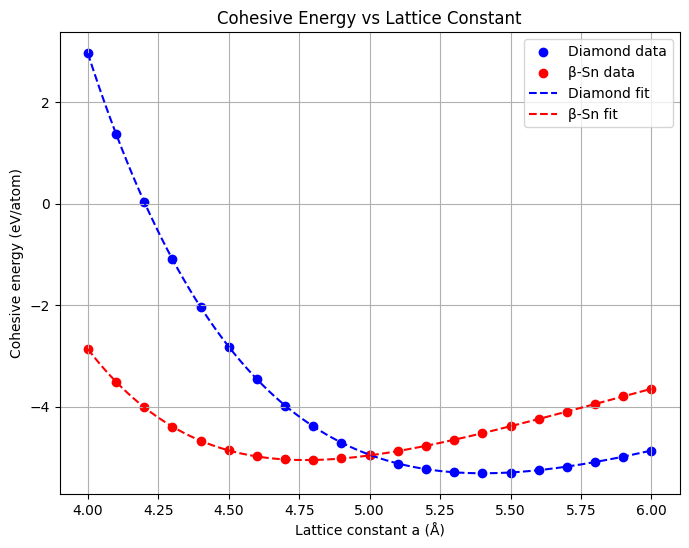

In [14]:

def poly6(x,a,b,c,d,e,f,g):
    return a*x**6 + b*x**5 + c*x**4 + d*x**3 + e*x**2 + f*x + g

popt_dia,_ = curve_fit(poly6, df['a (Å)'], df['Ec_diamond (eV)'])
popt_beta,_ = curve_fit(poly6, df['a (Å)'], df['Ec_betaSn (eV)'])

a_smooth = np.linspace(4.0,6.0,300)
Ec_dia_fit = poly6(a_smooth, *popt_dia)
Ec_beta_fit = poly6(a_smooth, *popt_beta)

a_eq_dia = a_smooth[np.argmin(Ec_dia_fit)]
a_eq_beta = a_smooth[np.argmin(Ec_beta_fit)]
Ec_eq_dia = np.min(Ec_dia_fit)
Ec_eq_beta = np.min(Ec_beta_fit)

print(f"Diamond equilibrium: a = {a_eq_dia:.3f} Å, Ec = {Ec_eq_dia:.3f} eV/atom")
print(f"β-Sn equilibrium: a = {a_eq_beta:.3f} Å, Ec = {Ec_eq_beta:.3f} eV/atom")

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df['a (Å)'], df['Ec_diamond (eV)'], color='blue', label='Diamond data')
plt.scatter(df['a (Å)'], df['Ec_betaSn (eV)'], color='red', label='β-Sn data')
plt.plot(a_smooth, Ec_dia_fit, '--b', label='Diamond fit')
plt.plot(a_smooth, Ec_beta_fit, '--r', label='β-Sn fit')
plt.xlabel('Lattice constant a (Å)')
plt.ylabel('Cohesive energy (eV/atom)')
plt.title('Cohesive Energy vs Lattice Constant')
plt.legend()
plt.grid(True)
plt.show()


### Exercise 1B

*How do your results compare to the experimental data by [Hu et al.](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.34.4679)*

According to the work by Hu et al., the lattice constant for diamond silicon (at 11.3 GPa) is $5.268 \pm 0.010Å$ and for β-Sn is $4.69\pm0.006Å$. My fitted results indicate the lattice constants for the two structured silicon are 5.405 Å and 4.776 Å, respectively. If taking the reference as a benchmark, the relative errors of the fitted parameters are 2.60% and 1.83%, respectively.

## Exercise 2: Structural Stability and Phase Diagrams Under Pressure

### Exercise 2A

*Using the data in Table 1 plot the enthalpy of silicon (in eV) as a function of the volume per atom (in $Å^3$), both for the diamond structure and the β-Sn structure, for the pressures $P_1$ = 0.01 GPa, $P_2$ = 8 GPa, and $P_3$ = 11 GPa.*

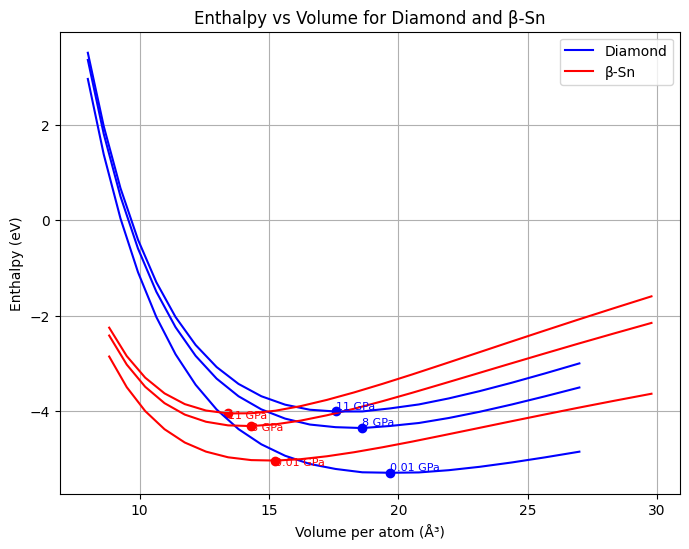

,Pressure (GPa),Diamond_Hmin (eV),Diamond_Vmin (Å³/atom),β-Sn_Hmin (eV),β-Sn_Vmin (Å³/atom)
0,0.01,-5.298771,19.683000,-5.043048,15.250637
1,8.00,-4.360783,18.609625,-4.319113,14.317192
2,11.00,-4.013292,17.576000,-4.053448,13.422634


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P_values = [0.01, 8, 11]
conv = 1 / 160.21766208

V_dia = df['a (Å)']**3 / 8
V_beta = (df['a (Å)']**3 * 0.5516) / 4

results = []
plt.figure(figsize=(8,6))

for P in P_values:
    H_dia = df['Ec_diamond (eV)'] + P * V_dia * conv
    H_beta = df['Ec_betaSn (eV)'] + P * V_beta * conv
    idx_dia_min = np.argmin(H_dia)
    idx_beta_min = np.argmin(H_beta)
    results.append({
        'Pressure (GPa)': P,
        'Diamond_Hmin (eV)': H_dia.iloc[idx_dia_min],
        'Diamond_Vmin (Å³/atom)': V_dia.iloc[idx_dia_min],
        'β-Sn_Hmin (eV)': H_beta.iloc[idx_beta_min],
        'β-Sn_Vmin (Å³/atom)': V_beta.iloc[idx_beta_min]
    })
    plt.plot(V_dia, H_dia, 'b-', alpha=1.0)
    plt.plot(V_beta, H_beta, 'r-', alpha=1.0)
    plt.scatter(V_dia.iloc[idx_dia_min], H_dia.iloc[idx_dia_min], color='b')
    plt.scatter(V_beta.iloc[idx_beta_min], H_beta.iloc[idx_beta_min], color='r')
    plt.text(V_dia.iloc[idx_dia_min], H_dia.iloc[idx_dia_min]+0.05, f'{P} GPa', color='b', fontsize=8)
    plt.text(V_beta.iloc[idx_beta_min], H_beta.iloc[idx_beta_min]-0.1, f'{P} GPa', color='r', fontsize=8)

plt.xlabel('Volume per atom (Å³)')
plt.ylabel('Enthalpy (eV)')
plt.title('Enthalpy vs Volume for Diamond and β-Sn')
plt.legend(['Diamond','β-Sn'])
plt.grid(True)
plt.show()

result_df = pd.DataFrame(results)
display(result_df)


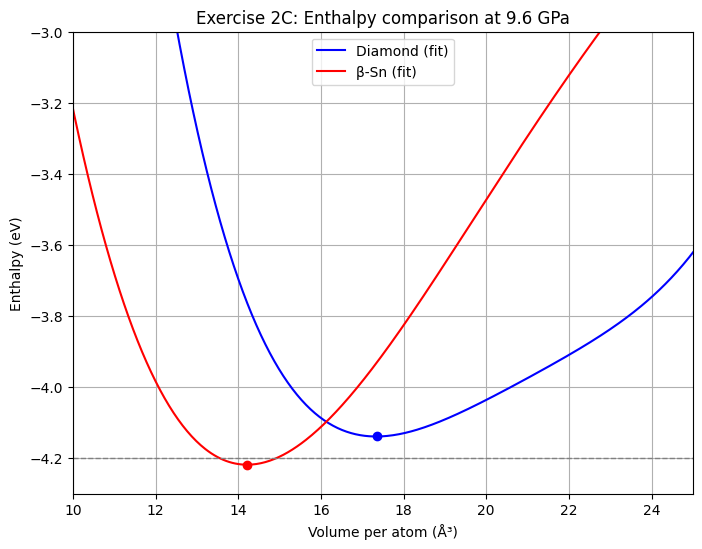

,Pressure (GPa),Diamond_Hmin_fit (eV),Diamond_Vmin_fit (Å³/atom),β-Sn_Hmin_fit (eV),β-Sn_Vmin_fit (Å³/atom)
0,9.6,-4.138822,17.34742,-4.218211,14.21949


,Pressure (GPa),Diamond_Hmin_raw (eV),β-Sn_Hmin_raw (eV),ΔH (Dia-βSn)
0,9.6,-4.174939,-4.176136,0.001196


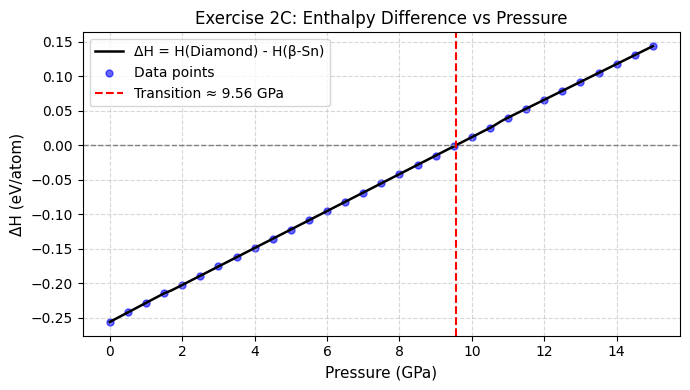

,Transition_Pressure (GPa)
0,9.5554


  • Direct minima method gives transition P ≈ 9.56 GPa
  • At 9.6 GPa: Diamond_Hmin = -3.5745 eV, β-Sn_Hmin = -3.7183 eV (ΔH ≈ +0.1438 eV)
  ⇒ Verified: at ~9.6 GPa, the two phases have nearly equal enthalpy, consistent with given LDA result.


In [16]:

from scipy.optimize import curve_fit

conv = 1 / 160.21766208  # 1 GPa·Å³ = 1/160.217 eV
V_dia = df['a (Å)']**3 / 8
V_beta = (df['a (Å)']**3 * 0.5516) / 4


def poly4(x, a, b, c, d, e):
    return a*x**4 + b*x**3 + c*x**2 + d*x + e

P = 9.6
H_dia = df['Ec_diamond (eV)'] + P * V_dia * conv
H_beta = df['Ec_betaSn (eV)'] + P * V_beta * conv

popt_dia, _ = curve_fit(poly4, V_dia, H_dia, maxfev=10000)
popt_beta, _ = curve_fit(poly4, V_beta, H_beta, maxfev=10000)

V_fit = np.linspace(min(V_beta.min(), V_dia.min()), max(V_beta.max(), V_dia.max()), 600)
H_dia_fit = poly4(V_fit, *popt_dia)
H_beta_fit = poly4(V_fit, *popt_beta)

idx_dia_min = np.argmin(H_dia_fit)
idx_beta_min = np.argmin(H_beta_fit)

plt.figure(figsize=(8,6))
plt.plot(V_fit, H_dia_fit, 'b-', label='Diamond (fit)')
plt.plot(V_fit, H_beta_fit, 'r-', label='β-Sn (fit)')
plt.scatter(V_fit[idx_dia_min], H_dia_fit[idx_dia_min], color='b', zorder=5)
plt.scatter(V_fit[idx_beta_min], H_beta_fit[idx_beta_min], color='r', zorder=5)
plt.axhline(y=-4.2, color='gray', linestyle='--', linewidth=1)
plt.xlim(10, 25)
plt.ylim(-4.3, -3.0)
plt.xlabel('Volume per atom (Å³)')
plt.ylabel('Enthalpy (eV)')
plt.title('Exercise 2C: Enthalpy comparison at 9.6 GPa')
plt.legend()
plt.grid(True)
plt.show()

result_fit = pd.DataFrame([{
    'Pressure (GPa)': P,
    'Diamond_Hmin_fit (eV)': H_dia_fit[idx_dia_min],
    'Diamond_Vmin_fit (Å³/atom)': V_fit[idx_dia_min],
    'β-Sn_Hmin_fit (eV)': H_beta_fit[idx_beta_min],
    'β-Sn_Vmin_fit (Å³/atom)': V_fit[idx_beta_min]
}])
display(result_fit)

def H_min_at_P(P):
    H_dia = df['Ec_diamond (eV)'] + P * V_dia * conv
    H_beta = df['Ec_betaSn (eV)'] + P * V_beta * conv
    return H_dia.min(), H_beta.min()

hd_min, hb_min = H_min_at_P(9.6)
result_direct = pd.DataFrame([{
    'Pressure (GPa)': 9.6,
    'Diamond_Hmin_raw (eV)': hd_min,
    'β-Sn_Hmin_raw (eV)': hb_min,
    'ΔH (Dia-βSn)': hd_min - hb_min
}])
display(result_direct)

Ps = np.linspace(0, 15, 151)
diffs = []
for P in Ps:
    hd_min, hb_min = H_min_at_P(P)
    diffs.append(hd_min - hb_min)

cross_idx = np.where(np.sign(diffs[:-1]) != np.sign(diffs[1:]))[0][0]
P_low, P_high = Ps[cross_idx], Ps[cross_idx+1]
P_fine = np.linspace(P_low, P_high, 1001)
diffs_fine = [H_min_at_P(P)[0] - H_min_at_P(P)[1] for P in P_fine]
P_transition = P_fine[np.argmin(np.abs(diffs_fine))]


plt.figure(figsize=(7,4))
plt.plot(Ps, diffs, 'k-', linewidth=1.8, label='ΔH = H(Diamond) - H(β-Sn)')
plt.scatter(Ps[::5], np.array(diffs)[::5], color='blue', s=25, alpha=0.6, label='Data points')  # 每隔5个点显示散点
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(P_transition, color='r', linestyle='--', linewidth=1.5, label=f'Transition ≈ {P_transition:.2f} GPa')

plt.xlabel('Pressure (GPa)', fontsize=11)
plt.ylabel('ΔH (eV/atom)', fontsize=11)
plt.title('Exercise 2C: Enthalpy Difference vs Pressure', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

result_transition = pd.DataFrame([{
    'Transition_Pressure (GPa)': P_transition
}])
display(result_transition)

print(f"  • Direct minima method gives transition P ≈ {P_transition:.2f} GPa")
print(f"  • At 9.6 GPa: Diamond_Hmin = {hd_min:.4f} eV, β-Sn_Hmin = {hb_min:.4f} eV (ΔH ≈ {hd_min - hb_min:+.4f} eV)")
print("  ⇒ Verified: at ~9.6 GPa, the two phases have nearly equal enthalpy, consistent with given LDA result.")


## Exercise 3: Vibrational Properties of Solids

### Exercise 3A

*Calculate the phonon dispersion curve of silicon on a $4\times4\times4$ q-point grid for the equilibrium volume, a volume 5% larger than equilibrium and a volume 5% smaller. Present all three curves on the same plot. Notice which phonon modes change their frequencies as the volume changes.*

From my HW2, the calculated equilibrium lattice constant of aluminum is 10.205 Bohr. When the total volume of the primitive cell are deformed $\pm 5\%$), the corresponding lattice constants are 10.032 and 10.372 Bohr, respectively. Recalling HW2 we also know that optimal cutoff energy is 40 Ry, respectively. Applying these parameters and compute the phonon dispersion we hence generate the following figure, where the blue line denotes the undeformed silicon and the black and red lines denote the silicon are deformed +5% and -5%.

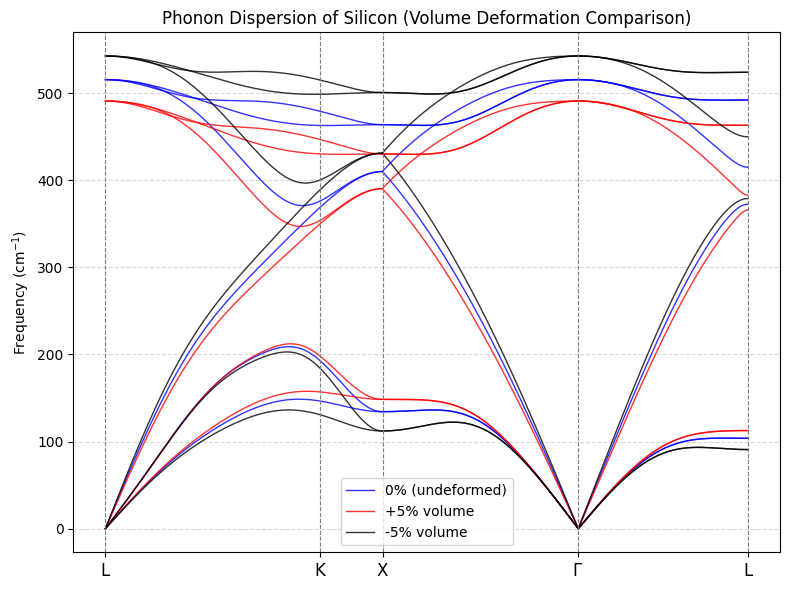

In [17]:
import requests
import numpy as np
import matplotlib.pyplot as plt

datasets = {
    "0% (undeformed)": "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW3/si_phonons_test_000/silicon_undeform.xmgr",
    "+5% volume": "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW3/si_phonons_test_005/silicon_plus5.xmgr",
    "-5% volume": "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW3/si_phonons_test_00_5/silicon_minus5.xmgr",
}

colors = {
    "0% (undeformed)": "blue",
    "+5% volume": "red",
    "-5% volume": "black",
}

plt.figure(figsize=(8, 6))

def load_bands(url):
    """从 GitHub 读取并解析 .xmgr 数据"""
    response = requests.get(url)
    if response.status_code != 200:
        raise RuntimeError(f"Failed to fetch data: {url}")
    content = response.text.strip()
    bands_raw = content.split("\n\n")
    bands = []
    for band in bands_raw:
        data = np.loadtxt(band.splitlines())
        k = data[:, 0]
        freq = data[:, 1]   
        bands.append((k, freq))
    return bands

def find_breaks(k_paths):
    breaks = []
    for i in range(1, len(k_paths[0])):
        if abs(k_paths[0][i] - k_paths[0][i-1]) > 0.1:
            breaks.append(i)
    return breaks

for label, url in datasets.items():
    bands = load_bands(url)
    breaks = find_breaks([k for k, f in bands])
    for k, f in bands:
        start_idx = 0
        for break_idx in breaks:
            end_idx = break_idx
            plt.plot(k[start_idx:end_idx], f[start_idx:end_idx],
                     color=colors[label], linewidth=1, alpha=0.8)
            start_idx = end_idx
        plt.plot(k[start_idx:], f[start_idx:], color=colors[label],
                 linewidth=1, alpha=0.8, label=label if k is bands[0][0] else "")


high_sym_points = [0, 0.86603*1.266, 1.415, 2.413, 3.28]
labels = ['L', 'K', 'X', r'$\Gamma$', 'L']

for x in high_sym_points:
    plt.axvline(x, color='gray', linestyle='--', linewidth=0.8)

plt.xticks(high_sym_points, labels, fontsize=12)
plt.ylabel("Frequency (cm$^{-1}$)")
plt.title("Phonon Dispersion of Silicon (Volume Deformation Comparison)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


###  Exercise 3B

*Calculate the bulk modulus for silicon based on calculations performed for previous homework assignments.*

According to the given equation: $$B = \frac{1}{3} (C_{11} + 2C_{12})$$

Based on the results from HW2, the values of the two elastic constants: $C_{11} = 161.70\rm GPa$ and $C_{12} =65.09\rm GPa$. The bulk modulus of silicon is $B = 97.293\rm GPa$. If taking the work by George [[2](https://sense.fas.sfu.ca/internal/Si_elastic.pdf)] as a reference, the bulk modulus of silicon is 97.84GPa, my computed results has a relative error of 0.55%.

### Exercise 3C

*Calculate the relevant elastic constants for $\rm PbTiO_3$ and invert the matrix to find the elements of $\bf S$ required to evaluate $α_a$ and $α_c$. You will need to fully relax the lattice constants and atomic coordinates first. Since $\rm PbTiO_3$ is not cubic, you will also need to relax the atomic coordinates for each strain value.*

The energy cutoff and lattice constants of $\rm PbTiO_3$ ae first converged using the same methods as in HW1, where the convergence criteria is met when the energy difference is less than 10 meV/Å, same as in HW1:

In [18]:
import os
import re
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

cutoffs = list(range(20, 151, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"[! ]\s*total energy\s*=\s*(-?\d+\.\d+)")

[20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


In [19]:
for cutoff in cutoffs:
    url = (
        f"https://raw.githubusercontent.com/"
        f"chemerzhc/Cornell-MSE5720-Assignment/"
        f"main/HW3/PTO/energy_cutoff/pto_{cutoff}/pto_{cutoff}.out"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy:.8f} Ry")
    else:
        print(f"⚠️ No energy found in {url}")
        energies.append(None)

print("\nEnergies collected:")
for cutoff, energy in zip(cutoffs, energies):
    print(f"ecutwfc = {cutoff} Ry → total energy = {energy}")

Cutoff 20: Energy = -379.50662250 Ry
Cutoff 30: Energy = -380.03418183 Ry
Cutoff 40: Energy = -380.04412881 Ry
Cutoff 50: Energy = -380.04920042 Ry
Cutoff 60: Energy = -380.04866896 Ry
Cutoff 70: Energy = -380.04361453 Ry
Cutoff 80: Energy = -380.04365428 Ry
Cutoff 90: Energy = -380.04498546 Ry
Cutoff 100: Energy = -380.04616390 Ry
Cutoff 110: Energy = -380.04480854 Ry
Cutoff 120: Energy = -380.04520684 Ry
Cutoff 130: Energy = -380.04463592 Ry
Cutoff 140: Energy = -380.04615522 Ry
Cutoff 150: Energy = -380.04593702 Ry

Energies collected:
ecutwfc = 20 Ry → total energy = -379.5066225
ecutwfc = 30 Ry → total energy = -380.03418183
ecutwfc = 40 Ry → total energy = -380.04412881
ecutwfc = 50 Ry → total energy = -380.04920042
ecutwfc = 60 Ry → total energy = -380.04866896
ecutwfc = 70 Ry → total energy = -380.04361453
ecutwfc = 80 Ry → total energy = -380.04365428
ecutwfc = 90 Ry → total energy = -380.04498546
ecutwfc = 100 Ry → total energy = -380.0461639
ecutwfc = 110 Ry → total energy =

cutoffs: 14 [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
energies: 14 [-379.5066225, -380.03418183, -380.04412881, -380.04920042, -380.04866896, -380.04361453, -380.04365428, -380.04498546, -380.0461639, -380.04480854, -380.04520684, -380.04463592, -380.04615522, -380.04593702]


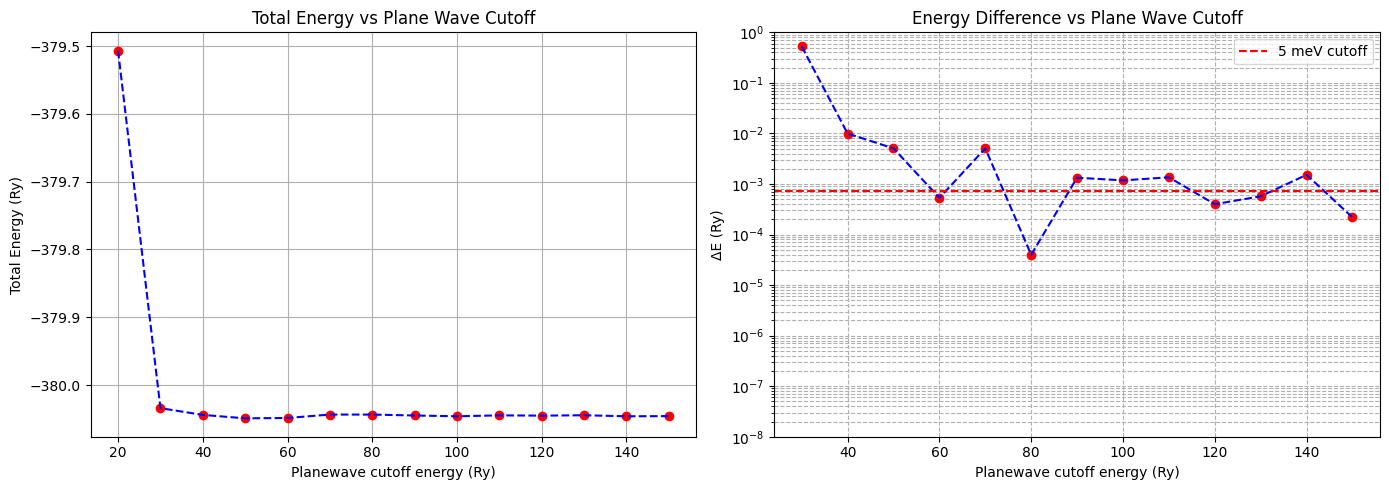

In [20]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'ro')
axes[0].plot(cutoffs, energies, linestyle='--', color='blue')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'ro')
axes[1].plot(cutoffs, delta_energies, linestyle='--', color='blue')
axes[1].axhline(10e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [22]:
forces = []
force_pattern = re.compile(r"Total force\s*=\s*([0-9.]+)")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [23]:
for k in range(2, 13):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW3/PTO/kpoints/pto_k{k}/pto_k{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text
    match = force_pattern.search(content)
    if match:
        force = float(match.group(1))
        forces.append(force)
        print(f"K-point {k}: Total force = {force}")
    else:
        print(f"⚠️ No total force found in {url}")
        forces.append(None)

K-point 2: Total force = 0.086973
K-point 3: Total force = 0.028903
K-point 4: Total force = 0.024846
K-point 5: Total force = 0.024582
K-point 6: Total force = 0.024634
K-point 7: Total force = 0.024665
K-point 8: Total force = 0.024603
K-point 9: Total force = 0.024675
K-point 10: Total force = 0.02466
K-point 11: Total force = 0.0246
K-point 12: Total force = 0.024604


[None, 0.05807, 0.004057000000000002, 0.00026400000000000035, 5.199999999999996e-05, 3.099999999999978e-05, 6.199999999999956e-05, 7.199999999999915e-05, 1.4999999999997654e-05, 6.0000000000001025e-05, 4.000000000000531e-06]


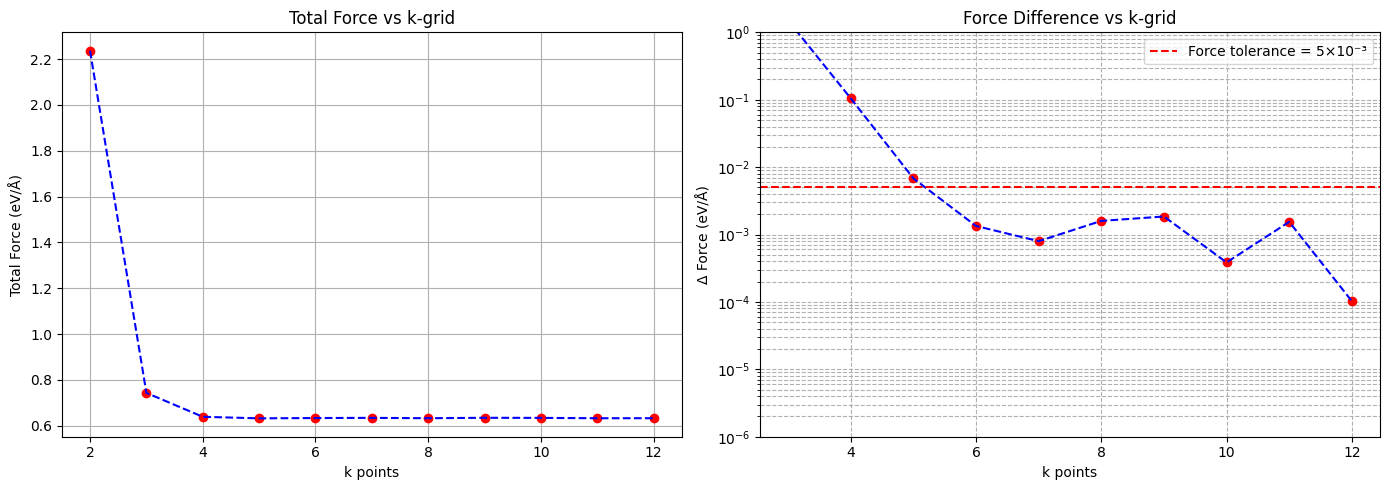

In [24]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))

print(delta_forces)
import numpy as np
forces = np.array(forces, dtype=float)
delta_forces = np.array(delta_forces, dtype=float)
factor = 13.605693 /0.529177
forces *= factor
delta_forces *= factor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, forces, 'ro')
axes[0].plot(ks, forces, linestyle='--', color='blue')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Force (eV/Å)")
axes[0].set_title("Total Force vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_forces, 'ro')
axes[1].plot(ks, delta_forces, linestyle='--', color='blue')
axes[1].axhline(5e-3, color='r', linestyle='--', label="Force tolerance = 5×10⁻³")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ Force (eV/Å)")
axes[1].set_title("Force Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

From the above figures it can be deduced that the converged energy cutoff and k points for $\rm PbTiO_3$ are 80 Ry and [6, 6, 6], respectively. 

we first compute the converged lattice constant using method ```'vc-relax'```, the converged lattice constants matrix ($\tt CELL\_PARAMETERS$)


Begin final coordinates

     new unit-cell volume =    406.47517 a.u.^3 (    60.23341 Ang^3 )

     density =      8.35543 g/cm^3


CELL_PARAMETERS (angstrom)

   3.855518365   0.000000000   0.000000000

   0.000000000   3.855518365   0.000000000

   0.000000000   0.000000000   4.052022654


ATOMIC_POSITIONS (crystal)

Pb               0.0000000000        0.0000000000        1.0051738283

Ti               0.5000000000        0.5000000000        0.5395344294

O                0.5000000000        0.5000000000        0.0995079024

O                0.5000000000        0.0000000000        0.6115340639

O                0.0000000000        0.5000000000        0.6115340639

End final coordinates''

Following the same procedure as in HW2, we apply the ```'relax'``` calculation methods. For the cell parameters $\mathcal{C}$, considering different different strains $\eta = [-0.006, -0.004, -0.002, 0, 0.002, 0.004, 0.006]$, $\mathcal{C}$ are computed as follows:

$$
\mathcal{C} = \begin{bmatrix}\mathbb{C} + \eta \mathbf{T} \mathbb{C} \end{bmatrix}
$$where $\mathbb{C}$ denotes the undeformed primitive cell box cell parameters and $\mathbf T$ are given in the instructions. We also generate a MATLAB code to obtain the cell parameters for deforming the primitive cell. Note that the undeformed volume $V_0$ of the primitive cell is 406.4721 $\rm bohr^3$.


Substitute the above contents into the in script and obtain the elastic constants from the given instructions: taking different strains, then the second-order parameters can be fitted as follows: 



* From this figure we can conclude that the second-order fit is $C_{11} = 14710.5\times 0.01311 = 192.8547 \rm GPa$.



* From this figure we can conclude that the second-order fit is $C_{33} = 14710.5\times 0.0154 = 226.5417 \rm GPa$.



* From this figure we can conclude that the second-order fit is $2(C_{11} - C_{12}) = 14710.5\times 0.01382 = 203.2991 \rm GPa$. Hence, we can compute $C_{12} =   192.8547 - 101.6496 =  91.2051 \rm GPa$.


* From this figure we can conclude that the second-order fit is $C_{11} + C_{33} - 2C_{13} = 14710.5\times 0.01064 = 156.5197 \rm GPa$. Hence, we can compute $C_{13} =   \frac{192.8547+226.5417-156.5197}{2} = 131.4384 \rm GPa$.

We can thence write out the matrix for elastic constants: 
$$
\mathbf{C} = \begin{bmatrix}
192.8547 & 91.2051 & 131.4384\\
91.2051 & 192.8547 & 131.4384\\
131.4384 & 131.4384 & 226.5417
\end{bmatrix}
$$

Writing in the SI unit (Pascal), the matrix writes:

$$
\mathbf{C} = \begin{bmatrix}
192.8547\times 10^9 & 91.2051\times 10^9 & 131.4384\times 10^9\\
91.2051\times 10^9 & 192.8547\times 10^9 & 131.4384\times 10^9\\
131.4384\times 10^9 & 131.4384\times 10^9 & 226.5417\times 10^9
\end{bmatrix}
$$

By inverting the matrix we can obtain $\bf S$ (in reverse of GPa):
$$
\mathbf{S} = \begin{bmatrix}
0.0087 & -0.0011  & -0.0044\\
-0.0011 & 0.0087 & -0.0044\\
-0.0044 & -0.0044& 0.0095\\
\end{bmatrix}
$$

Therefore, the elements of $\bf S$ for evaluating the thermal coefficients can be obtained: $S_{11} = 0.0087,\ S_{33} = 0.0095,\ S_{12} = -0.0011,\ S_{13} = -0.0044$.



### Exercise 3D

*While E. Coyote of Acme Labs measured the bulk Grüneisen parameters for silicon and $\rm PbTiO_3$. For Si, he measured a value of $γ_{bulk} = 2$ and for $\rm PbTiO_3$, he obtained the results $γ_{bulk}^c = 0.4$ and $γ_{bulk}^a = 1.7$. Using these values, and your calculated results for the bulk modulus of Si and the compliance matrix elements for $\rm PbTiO_3$, evaluate $α_v$ for silicon and $α_a$ and $α_c$ for $\rm PbTiO_3$. A negative value of $α$ means that the material undergoes negative thermal expansion. Do either Si or $\rm PbTiO_3$ exhibit negative thermal expansion? Note that for $\rm PbTiO_3$ you should evaluate $\alpha_v = 2α_a +\alpha_c$. Thermal expansion coefficients have units of inverse temperature. Since we are only estimating the coefficients (the expressions above are missing some unimportant – for us – constants), they will have units of inverse pressure, since Grüneisen parameters are dimensionless. Is negative thermal expansion observed experimentally for either Si or $\rm PbTiO_3$?*

For $\rm PbTiO_3$, taking the equations from the instructions, we write:

$$\alpha_a \sim \left[ (S_{11} + S_{12})\gamma_{\rm bulk}^a + S_{13} \gamma_{\rm bulk}^c \right] $$ and $$\alpha_c \sim \left[ 2 S_{13} \gamma_{\rm bulk}^a + S_{33} \gamma_{\rm bulk}^c  \right] $$

From Exercise 2, we substitute the obtained $S$ values into the equations and compute the corresponding thermal expansion coefficients:

$$
\alpha_a \sim (0.0087 - 0.0011) \times 0.4 - 0.0044 \times 1.7 =  -0.0044\\
\alpha_c \sim 2 \times (-0.0044) \times 0.4 + 0.0095 \times 1.7 = 0.0126
$$

we then obtain $\alpha_v = 2\alpha_a + \alpha_c =  0.0038\times \rm \ GPa^{-1}$.

It can be deduced that $\rm PbTiO_3$ does not possess a negative thermal coefficient.

For silicon, the thermal coefficient writes: $\alpha = \frac{\gamma_{bulk}}{B} = \frac{2}{98.0733}\times 10^{-9} = 0.0204\rm \ GPa^{-1}$.

It can be deduced that silicon does not possess a negative thermal coefficient.